In [35]:
import pandas as pd 
from sklearn.metrics import accuracy_score, classification_report, auc, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

In [3]:
frameshift_file = '/Users/edatkinson/Repos/Modelling/data/pmed_log_frameshift.csv'
inframe_file = '/Users/edatkinson/Repos/Modelling/data/pmed_log_inframe.csv'

def prepare_data(file, model_type = None):
    """ 
    file: data_file to be transformed into the correct format for the specified type: 'CADD', 'sift', 'PredCID', 'VEST-indel' 

    """
    df = pd.read_csv(file, sep=',')


    # Open the output VCF file for writing
    with open(f'/Users/edatkinson/Repos/Modelling/pmed_log_inframe.vcf', 'w') as vcf:
        # Write VCF header lines
        vcf.write("##fileformat=VCFv4.2\n")
        vcf.write("##INFO=<ID=DS,Number=1,Type=String,Description=\"driver_stat\">\n")
        vcf.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        
        # Iterate over each row in the DataFrame and write VCF records
        for index, row in df.iterrows():
            chrom = row['chrom']
            pos = row['pos']
            ref = row['ref_allele']
            alt = row['alt_allele']
            driver_stat = row['driver_stat']
            
            # Construct the INFO field with driver_stat
            info = f"DS={driver_stat}"
            
            # Create the VCF record; we use '.' for ID, QUAL, and FILTER
            vcf_line = f"{chrom}\t{pos}\t.\t{ref}\t{alt}\t.\t.\t{info}\n"
            vcf.write(vcf_line)

prepare_data(inframe_file)

In [11]:
import pandas as pd

def make_sift(file):
    df = pd.read_csv(file, sep=',')
    # Open the output SIFT-format text file for writing
    with open('/Users/edatkinson/Repos/Modelling/testing/pmed_log_inframe_sift.txt', 'w') as outf:
        for _, row in df.iterrows():
            chrom = row['chrom'].split('chr')[-1]
            pos = int(row['pos'])
            ref = str(row['ref_allele'])
            alt = str(row['alt_allele'])
            # Use driver_stat as a comment if provided; if empty, no comment is appended.
            #comment = str(row['driver_stat']) if pd.notnull(row['driver_stat']) else ""
            
            # Determine if the variant is a deletion.
            # Either alt allele is "/" or the ref allele is longer than the alt allele.
            if alt == "/" or (len(ref) > len(alt)):
                if alt == "/":
                    deletion_length = len(ref)
                else:
                    deletion_length = len(ref) - len(alt)
                end = pos + deletion_length
            else:
                # For insertions and SNPs, the coordinates are the same.
                end = pos
            
            orientation = 1  # Default to positive strand
            
            # Build the SIFT format record:
            # Order: chromosome, start, end, orientation, allele, (optional comment)
            fields = [str(chrom), str(pos), str(end), str(orientation), alt]
            
            line = ",".join(fields)
            outf.write(line + "\n")

    print("SIFT format file created at: /Users/edatkinson/Repos/Modelling/testing/pmed_log_inframe_sift.txt")

make_sift(inframe_file)

SIFT format file created at: /Users/edatkinson/Repos/Modelling/testing/pmed_log_inframe_sift.txt


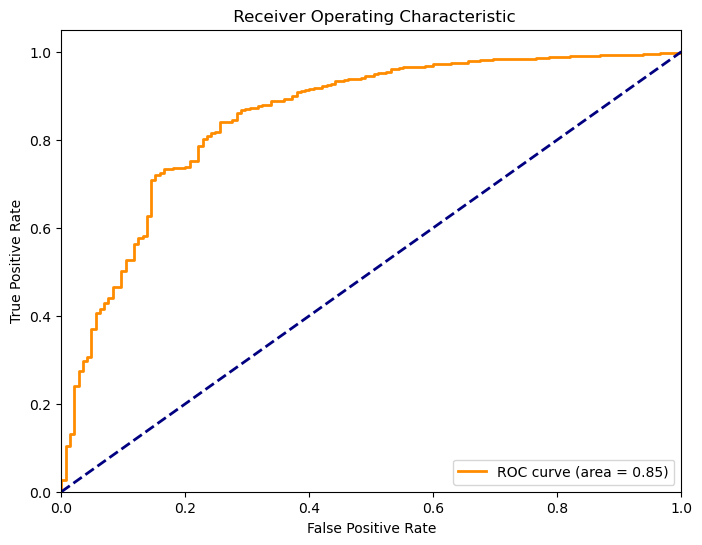

In [ ]:
# Manage CADD data
def plot_precision_recall_roc(y_true, y_proba, fig, ax, title_prefix=""):
    """
    Plots the precision-recall curve and ROC curve for a given set of true labels and predicted probabilities.

    Parameters:
    - y_true: True labels (binary).
    - y_proba: Predicted probabilities for the positive class.
    - title_prefix: Optional prefix for the plot titles.
    """
    
    # precision, recall, thresholds_pr = precision_recall_curve(y_true, 1-y_proba)
    # plt.figure(figsize=(8, 6))
    # plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve')
    # plt.xlabel('Recall')
    # plt.ylabel('Precision')
    # plt.title(f'{title_prefix} Precision-Recall Curve')
    # plt.legend(loc="lower left")
    # plt.xlim([0.0, 1.0])
    # plt.ylim([0.0, 1.05])
    # plt.show()

    

    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    
    ax.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{title_prefix} Receiver Operating Characteristic')
    ax.legend(loc="lower right")
    
    return fig, ax



def process_CADD_annotations(file):
    mydf = pd.read_csv('/Users/edatkinson/Repos/Modelling/data/pmed_log_frameshift.csv', sep=',')

    df = pd.read_csv(file, sep='\t', skiprows=1)
    df.rename(columns={'#Chrom':'chrom', 'Pos':'pos', 'Ref':'ref_allele', 'Alt':'alt_allele'}, inplace=True)
    df['chrom'] = df['chrom'].apply(lambda x: 'chr'+str(x))

    
    # Define a function to classify based on PHRED score
    def classify_variant(phred):
        if phred < 20:
            return 0
        else:
            return 1

    # Apply classification
    df['predicted'] = df['PHRED'].apply(classify_variant)
    # df['actual'] is the merged 
    merged = pd.merge(mydf, df, on=['chrom', 'pos', 'ref_allele', 'alt_allele'], how='right')

    # print(classification_report(merged['driver_stat'], merged['PHRED']))
    return merged





merged = process_CADD_annotations('/Users/edatkinson/Repos/Modelling/testing/cadd_frameshift.tsv')


